## Measure empirical PSFs on resampled NIRCam Images
SExtractor catalogs can be constructed using `empirical_cat.ipynb`

In [1]:
%matplotlib inline
import os
import glob
import numpy as np
from galfitx.source_detection import SExtractor_HDR
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import shutil
from astropy.stats import sigma_clipped_stats
from astropy.table import Table
from astropy.io import ascii
from astropy.visualization import simple_norm
from pathlib import Path
from typing import Optional, Tuple, List
import os
import sys
# ── import plotting helpers ───────────────────────────────────────────────────
import sys
from pathlib import Path as Path2
path = Path2('~/code_package').expanduser()
sys.path.append(str(path))
import matplotlib.pyplot as plt
from my_astro_tools import my_im_show,set_plot_style
set_plot_style()    

/home/zhanghan/anaconda3/envs/galfitx_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The SFD'98 dust map is not in the data directory:

    /home/zhanghan/anaconda3/envs/galfitx_env/lib/python3.12/site-packages/dustmaps/data

To change the data directory, call:

    from dustmaps.config import config
    config['data_dir'] = '/path/to/data/directory'

To download the SFD'98 map to the data directory, call:

    import dustmaps.sfd
    dustmaps.sfd.fetch()



In [2]:
sci_dir = '/RS2423/JWST/grism/data/direct_image/'
sci_files = sorted(glob.glob(os.path.join(sci_dir, '*resample.fits')))
fwhm_arcsec_list = {'F115W': 0.06, 'F200W':0.073, 'F356W':0.14}
print(sci_files)
print(len(sci_files))

['/RS2423/JWST/grism/data/direct_image/nircam_F115W_mosaic_resample.fits', '/RS2423/JWST/grism/data/direct_image/nircam_F200W_mosaic_resample.fits', '/RS2423/JWST/grism/data/direct_image/nircam_F356W_mosaic_resample.fits']
3


In [3]:
# ========================================================================
# User-defined parameters - modify these for your data
# ========================================================================

# Star selection criteria
mag_bright_limit = 19.0            # Bright magnitude limit
mag_faint_limit = 27.0             # Faint magnitude limit
elong_max = 1.5                    # Maximum elongation for star selection
class_star_min = 0.96              # Minimum star class

In [4]:
from psfex_helper import star_pre_select, star_master_cat
catalog_list = []
star_id_list = []
filter_names = []
for i, sci_file in enumerate(sci_files):
    band = sci_file.split('/')[-1].split('_')[1]
    filter_names.append(band)
    print(f"Processing file {i+1}/{len(sci_files)}/: {sci_file}, {band}")
    out_path = "/RS2423/JWST/grism/data/direct_image/sextractor/"+band+"/"
    print(f"selecting stars from {out_path}...") 
    catalog_file = out_path+"outcat_"+band 
    seg_file = out_path+"outseg_"+band+".fits" 
    outtab = ascii.read(catalog_file)
    catalog_list.append(outtab)
    _, star_id = star_pre_select(catalog_file=catalog_file,
                                        mag_bright_limit=mag_bright_limit,
                                        mag_faint_limit=mag_faint_limit,
                                        crossmatch=False,
                                        fwhm_arcsec=fwhm_arcsec_list[band],
                                        elong_max=elong_max,
                                        class_star_min=class_star_min
                                        )
    star_id_list.append(star_id)
star_id_list_master, catalog_master_list = star_master_cat(catalog_list, star_id_list, filter_names,
                                                            ra_col="ra", dec_col="dec",
                                                            id_col="label", mag_col="mag_auto",
                                                            match_radius=0.1 * u.arcsec,
                                                            color_pair=("F115W", "F356W"), color_min=-1.7)


Could not import regions, which is required for some of the functionalities of this module.
Processing file 1/3/: /RS2423/JWST/grism/data/direct_image/nircam_F115W_mosaic_resample.fits, F115W
selecting stars from /RS2423/JWST/grism/data/direct_image/sextractor/F115W/...
55 sources satisfy stellar criteria.
55 sources satisfy stellar criteria.
Processing file 2/3/: /RS2423/JWST/grism/data/direct_image/nircam_F200W_mosaic_resample.fits, F200W
selecting stars from /RS2423/JWST/grism/data/direct_image/sextractor/F200W/...
101 sources satisfy stellar criteria.
101 sources satisfy stellar criteria.
Processing file 3/3/: /RS2423/JWST/grism/data/direct_image/nircam_F356W_mosaic_resample.fits, F356W
selecting stars from /RS2423/JWST/grism/data/direct_image/sextractor/F356W/...
149 sources satisfy stellar criteria.
149 sources satisfy stellar criteria.


In [5]:
type(outtab[0]['label'])

numpy.int64

In [6]:
for i, star_id_master in enumerate(star_id_list_master):
    band = filter_names[i]
    print(f'Total selected stars: {len(star_id_master)} for {band}')

    table = Table([star_id_master], names=['star_id'])
    ascii.write(
        table,
        f'./data_example/star_ids_{band}.txt',
        comment=f'# selected star ids for {band}',
        overwrite=True
    )
    print(star_id_master)

Total selected stars: 31 for F115W
[ 5901  7507  7651  7684  8146  8638  8894  9230  9252  9589  9758 10237
 10462 11187 11691 12013 12369 12840 13494 13497 13788 14167 14298 15152
 16394 16761 16951 19830 19888 22384 22585]
Total selected stars: 31 for F200W
[10183 14081 14454 14548 15689 17070 17671 18419 18502 19031 19359 20443
 20944 22390 23334 23861 24597 25405 26496 26508 27072 27770 28044 29564
 32470 33248 33687 40738 40794 43652 43898]
Total selected stars: 31 for F356W
[ 1032  2505  2457  2535  2971  3369  3591  3816  3973  4241  4293  4591
  4898  5423  5929  6052  6497  6809  7400  7397  7600  7964  8103  8407
  9494  9659  9732 12061 12043 12782 12771]


In [7]:
print(type(star_id_list_master[0][0]))
data = ascii.read(f'./data_example/star_ids_{band}.txt', comment='#')
#print(data)
print(np.array(data['star_id']))

<class 'numpy.int64'>
[ 1032  2505  2457  2535  2971  3369  3591  3816  3973  4241  4293  4591
  4898  5423  5929  6052  6497  6809  7400  7397  7600  7964  8103  8407
  9494  9659  9732 12061 12043 12782 12771]


In [8]:
sci_file = sci_files[0]
band = sci_file.split('/')[-1].split('_')[-3]
print(sci_file, band)
out_path = "/RS2423/JWST/grism/data/direct_image/sextractor/"+band+"/"
psf_out_path = "/RS2423/JWST/grism/data/direct_image/psfex/"
os.makedirs(psf_out_path, exist_ok=True)
print(filter_names.index(band))
star_id_master = star_id_list_master[filter_names.index(band)]

/RS2423/JWST/grism/data/direct_image/nircam_F115W_mosaic_resample.fits F115W
0


In [9]:
print(f'Total selected stars: {len(star_id_master)} for {band}')

Total selected stars: 31 for F115W


In [ ]:
with fits.open(sci_file) as hdul:
    hdul.info()
    hdr = hdul[1].header
    data = hdul[1].data  # or hdul['SCI'].data
    coverage_mask = ((data == 0) | np.isnan(data))  # True for pixels with zero coverage or NaN
    print(f"Shape: {data.shape}")
    print(f"Min: {np.nanmin(data):.6f}")
    print(f"Max: {np.nanmax(data):.6f}")
    print(f"Mean: {np.nanmean(data):.6f}")
    print(f"Median: {np.nanmedian(data):.6f}")
    print(f"Std: {np.nanstd(data):.6f}") 

Filename: /RS2423/JWST/grism/data/direct_image/nircam_F115W_mosaic_resample.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     369   ()      
  1  SCI           1 ImageHDU        75   (21000, 12000)   float32   
  2  ERR           1 ImageHDU        10   (21000, 12000)   float32   
  3  CON           1 ImageHDU        10   (21000, 12000, 12)   int32   
  4  WHT           1 ImageHDU         9   (21000, 12000)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (21000, 12000)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (21000, 12000)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (21000, 12000)   float32   
  8  HDRTAB        1 BinTableHDU    536   384R x 263C   [23A, 5A, 3A, 48A, 7A, 13A, 6A, 5A, 6A, 7A, 10A, 4A, L, D, D, 4A, 24A, 40A, 15A, 3A, 9A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 2A, L, 39A, 10A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 10A, 23A, 5A, D, D, D, D, D, D, D, D, 7A, 6A, 5A, 1A, 5A, 

Shape: (12000, 21000)
Min: -0.718483
Max: 1321.718018
Mean: 0.009147


In [ ]:
pixel_sr = hdr['PIXAR_SR']
pixel_scale = np.sqrt(hdr['PIXAR_A2']) #arcsec/pixel
mag_zeropoint = -2.5 * np.log10((u.MJy / u.sr * (pixel_sr*u.sr**2) / (3631 * u.Jy)).cgs.value)
print(mag_zeropoint,pixel_scale) 

In [ ]:
print(np.sum(np.isfinite(data)))
print(np.sum(np.isnan(data)))

53792479
2387521


In [ ]:
print(f"Coverage mask: {np.sum(coverage_mask)}")

Coverage mask: 2387521


In [ ]:
from psfex_helper import build_input_ldac, psfex_config
from galfitx.create_psf import run_psfex

In [ ]:
# ========================================================================
# User-defined parameters - modify these for your data
# ========================================================================
sci_image = sci_file           # Path to science image
file_ext = 1
catalog_file = out_path+"outcat_"+band            # SExtractor catalog (ASCII)
seg_file = out_path+"outseg_"+band+".fits"           # SExtractor segmentation map
template_file = "/home/zhanghan/output_assoc_temp.cat"  # Template LDAC file

output_dir = psf_out_path # Output directory
output_ldac = psf_out_path + "psfex_" + band +".cat"           # Output LDAC catalog name

# Cutout parameters
cutout_size = 135                  # Size of star cutouts (pixels)

# PSFEx configuration parameters
psf_sampling = 0.5                 # Sampling step (0.0 = auto)
psf_size = (269, 269)              # Output PSF size
sample_minsn = 100                  # Minimum S/N for star selection

# Image metadata 
fwhm_arcsec = fwhm_arcsec_list[band]        # Approximate FWHM in arcsec
mag_zeropoint = mag_zeropoint               # Magnitude zero-point
ref_pixel_scale = pixel_scale       # Pixel scale (arcsec/pixel)

sample_fwhmrange_dict = {'F115W': "1,5", "F200W": "1,5", "F356W": "2,9", "F444W": "2,9"}  # FWHM range for star selection

In [ ]:
# ========================================================================
# Step 1: Build LDAC catalog for PSFEx
# ========================================================================
print("=" * 60)
print("Step 1: Building LDAC catalog for PSFEx")
print("=" * 60)

build_input_ldac(
    sci_image=sci_image,
    catalog_file=catalog_file,
    seg_file=seg_file,
    output_ldac=output_ldac,
    file_ext = file_ext,
    star_id_pre = star_id_master,
    mag_bright_limit=mag_bright_limit,
    mag_faint_limit=mag_faint_limit,
    cutout_size=cutout_size,
    save_cutouts=True,
    #crossmatch=True,
    cutouts_dir=os.path.join(output_dir, "star_cutouts_"+band),
    template_file=template_file,
    fwhm_arcsec=fwhm_arcsec,
    mag_zeropoint=mag_zeropoint,
    ref_pixel_scale=ref_pixel_scale,
    star_coords_path=os.path.join(output_dir, f"star_coords_{band}.txt")
)

# ========================================================================
# Step 2: Generate PSFEx configuration file
# ========================================================================
print("\n" + "=" * 60)
print("Step 2: Generating PSFEx configuration file (constant PSF)")
print("=" * 60)

config_file = os.path.join(output_dir, "config"+band+".psfex")
psfex_config(
    output_config=config_file,
    psf_sampling=psf_sampling,
    psf_size=psf_size,
    sample_autoselect=True,
    sample_fwhmrange=sample_fwhmrange_dict[band],
    sample_minsn=sample_minsn,
    psfvar_degrees=0,
    outcat_name=os.path.join(output_dir, "psfex_cat_"+band+".txt")  # Constant PSF
)

# ========================================================================
# Step 3: Run PSFEx
# ========================================================================
print("\n" + "=" * 60)
print("Step 3: Running PSFEx")
print("=" * 60)

psf_file = run_psfex(
    catalog=output_ldac,
    config=config_file,
    output_dir=output_dir,
)

print("\n" + "=" * 60)
print("PSFEx workflow completed successfully!")
print(f"PSF model saved to: {psf_file}")
print(f"Output directory: {output_dir}")
print("=" * 60)

Step 1: Building LDAC catalog for PSFEx
31 out of 31 stars are fully within the image and have been cut out.
Cropped star images saved to /RS2423/JWST/grism/data/direct_image/psfex/star_cutouts_F356W/
SNR values: [ 102.63305    91.14541    35.16904    33.8047    405.9622   3467.6519
  249.43417   870.0857    224.00526    92.03361   154.99654   624.7684
  217.55843   104.566986  528.59076   115.519966   42.87963   301.36676
   73.41623   285.30304   182.625     293.12592   283.81653    47.313156
   48.732906  293.56183   640.9296    236.31134  6758.344     119.52553
  130.15402 ]
LDAC 文件已生成: /RS2423/JWST/grism/data/direct_image/psfex/psfex_F356W.cat
已将 NAXIS1/2 更新为 10600, 5300

Step 2: Generating PSFEx configuration file (constant PSF)
Configuration written to /RS2423/JWST/grism/data/direct_image/psfex/configF356W.psfex

Step 3: Running PSFEx
Running PSFEx...


> 
----- PSFEx 3.17.1 started on 2026-07-21 at 11:07:14 with 1 thread

> 
----- 1 input catalogues:
psfex_F356W.cat     :  "no ident        "    1 extension      31 detections

> Initializing contexts...
> Reading data from psfex_F356W...
> Computing final PSF model for psfex_F356W...
   filename      [ext] accepted/total samp. chi2/dof FWHM ellip. resi. asym.
> Computing diagnostics for psfex_F356W...
psfex_F356W                 23/23      0.50   1.29   3.09  0.01  0.04  0.04
> Saving PSF model and metadata for psfex_F356W...
> 
> All done (in 2.0 s)


PSF model written to /RS2423/JWST/grism/data/direct_image/psfex/psfex_F356W.psf
PSF FITS saved to /RS2423/JWST/grism/data/direct_image/psfex/psfex_F356W_psf.fits
Radial profile saved to /RS2423/JWST/grism/data/direct_image/psfex/psfex_F356W_radial_profile.png
FWHM = 3.403821687740271

PSFEx workflow completed successfully!
PSF model saved to: /RS2423/JWST/grism/data/direct_image/psfex/psfex_F356W.psf
Output directory: /RS2423/JWST/grism/data/direct_image/psfex/


In [ ]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

psf_file = psf_out_path + "psfex_"+band+"_psf.fits"

with fits.open(psf_file) as hdul:
    hdul.info()
    psf_data = hdul[0].data  

Filename: /RS2423/JWST/grism/data/direct_image/psfex/psfex_F356W_psf.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (133, 133)   float64   


In [ ]:
from photutils.psf import fit_fwhm
print("="*60)
print(f"FWHM for empirical PSF: {band}")
print(f"pixel scale = {pixel_scale} arcsec/pixel")
fwhm_stacked_psfex = fit_fwhm(psf_data)[0] * pixel_scale
print(f"PSF FWHM = {fwhm_stacked_psfex} arcsec")

FWHM for empirical PSF: F356W
pixel scale = 0.04 arcsec/pixel
PSF FWHM = 0.13615286750961084 arcsec


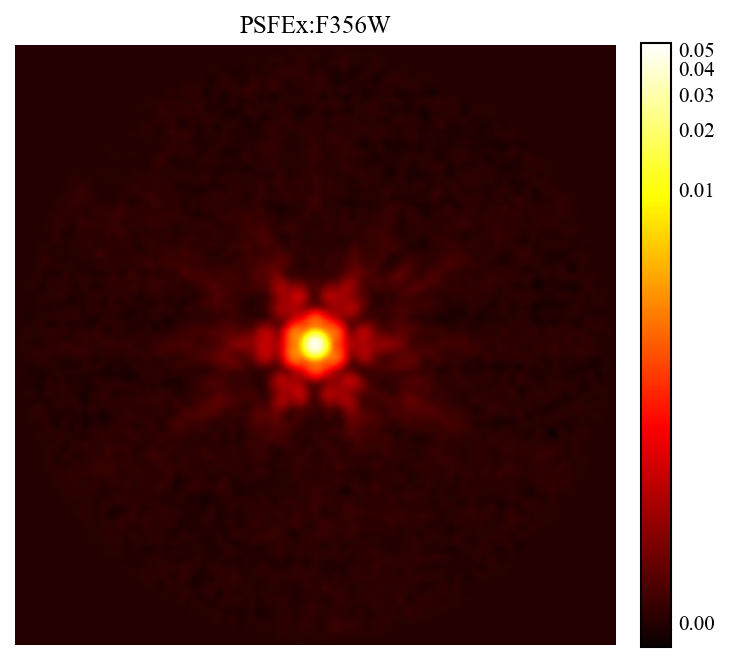

In [ ]:
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
%matplotlib inline
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
norm = simple_norm(psf_data, stretch='log')
im = ax.imshow(psf_data, cmap='hot', norm=norm, interpolation='gaussian', origin='lower')
ax.set_title("PSFEx:"+band)
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
# PSFEx output — NUMBER is the 1-indexed row in the input LDAC
psfex_cat = ascii.read(os.path.join(output_dir, "psfex_cat_"+band+".txt"))

# star_coordinates.txt has columns: x, y, original_label
coords = np.loadtxt(os.path.join(output_dir, "star_coordinates_"+band+".txt"))

matched_ids = []
for row in psfex_cat:
    x_psf, y_psf = row['X_IMAGE'], row['Y_IMAGE']
    dx = np.abs(coords[:, 0] - x_psf)
    dy = np.abs(coords[:, 1] - y_psf)
    dist = np.sqrt(dx**2 + dy**2)
    match_idx = np.argmin(dist)
    if dist[match_idx] < 1.0:
        matched_ids.append(int(coords[match_idx, 2]))

print("Stars used by PSFEx (original IDs):", matched_ids)

Stars used by PSFEx (original IDs): [1032, 2971, 3369, 3591, 3816, 3973, 4293, 4591, 4898, 5423, 5929, 6052, 6809, 7400, 7600, 7964, 8103, 9659, 9732, 12043, 12061, 12771, 12782]


In [ ]:
outtab = ascii.read(catalog_file)

In [ ]:
psf_outtab = outtab[np.isin(outtab['label'], matched_ids)]

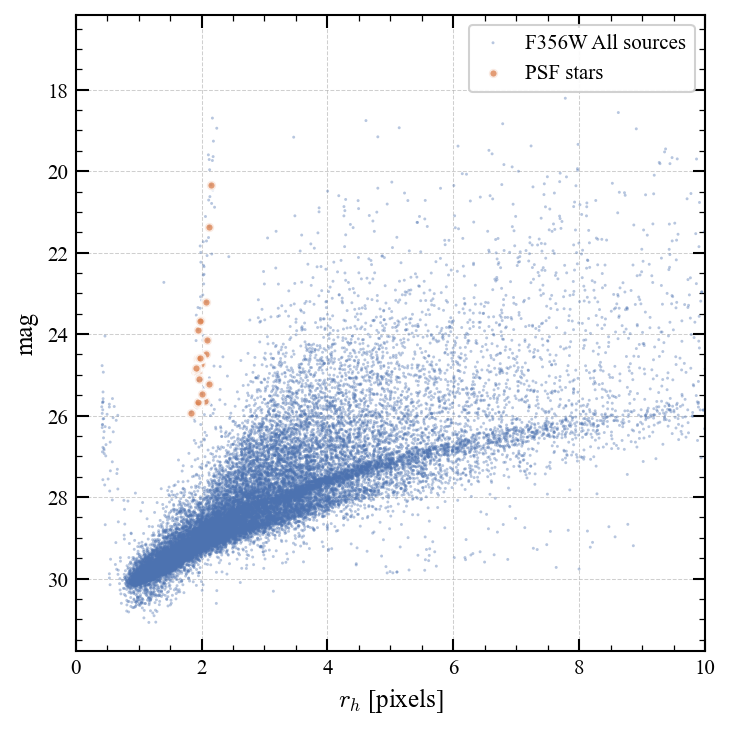

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax.scatter(outtab['flux_radius'], outtab['mag_auto'], s=2, alpha=0.4,
           color='#4C72B0', edgecolors='none', label=band +' All sources')
ax.scatter(psf_outtab['flux_radius'], psf_outtab['mag_auto'], s=20, alpha=0.8,
           color='#DD8452', edgecolors='white', linewidth=1.5, label='PSF stars')

ax.set_xlabel(r'$r_h$ [pixels]', fontsize=12)
ax.set_ylabel(r'mag', fontsize=12)
ax.invert_yaxis()
ax.grid(True, linestyle='--', alpha=0.6, linewidth=0.5)
ax.set_xlim(0, 10)
ax.legend(frameon=True, fancybox=True, framealpha=0.9, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
with fits.open(f'/home/zhanghan/J0100-15157/data/{band.lower()}_psfex_global.fits') as hdul:
    hdul.info()
    global_psf_data = hdul[0].data

Filename: /home/zhanghan/J0100-15157/data/f356w_psfex_global.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (151, 151)   float64   


In [ ]:
from photutils.psf import fit_fwhm
print("="*60)
print(f"FWHM for empirical PSF by Changhao")
print(f"pixel scale = {pixel_scale} arcsec/pixel")
fwhm_stacked_psfex2 = fit_fwhm(global_psf_data)[0] * pixel_scale
print(f"PSF FWHM = {fwhm_stacked_psfex2} arcsec")

FWHM for empirical PSF by Changhao
pixel scale = 0.04 arcsec/pixel
PSF FWHM = 0.1365329657296945 arcsec
